In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


In [ ]:
!wget -q https://raw.githubusercontent.com/neilvanthesman/Machine-Learning/refs/heads/main/spotify.csv
data = pd.read_csv('spotify.csv')
print(data.shape)
print(data.head())
print(data.isnull().sum())


(167293, 16)
                       id                 name  \
0  5dMJFsGH8e1XfPOAUyfZGS                True.   
1  0jdeV5dSB3kUBRqe1xQJbh                TRue.   
2  4q2lRiodoQnyFO65watkse                true.   
3  05BOCO1cK6iNmOYhjTTQit  Zzyzx Rd. - Pop Mix   
4  6mugfZWz63m4VwRgW9Pbrd      Zydrate Anatomy   

                                             artists  year  acousticness  \
0                                  ['George Strait']  1998        0.2540   
1                                   ['Ryan Cabrera']  2004        0.4590   
2                                 ['Spandau Ballet']  1986        0.3060   
3                                     ['Stone Sour']  2006        0.1910   
4  ['Paris Hilton', 'Alexa Vega', 'Terrance Zduni...  2008        0.0133   

   danceability  energy  instrumentalness  liveness  loudness  speechiness  \
0         0.590   0.669          0.000151    0.1430    -4.975       0.0268   
1         0.598   0.400          0.000000    0.1510   -10.054       0.024

# EDA

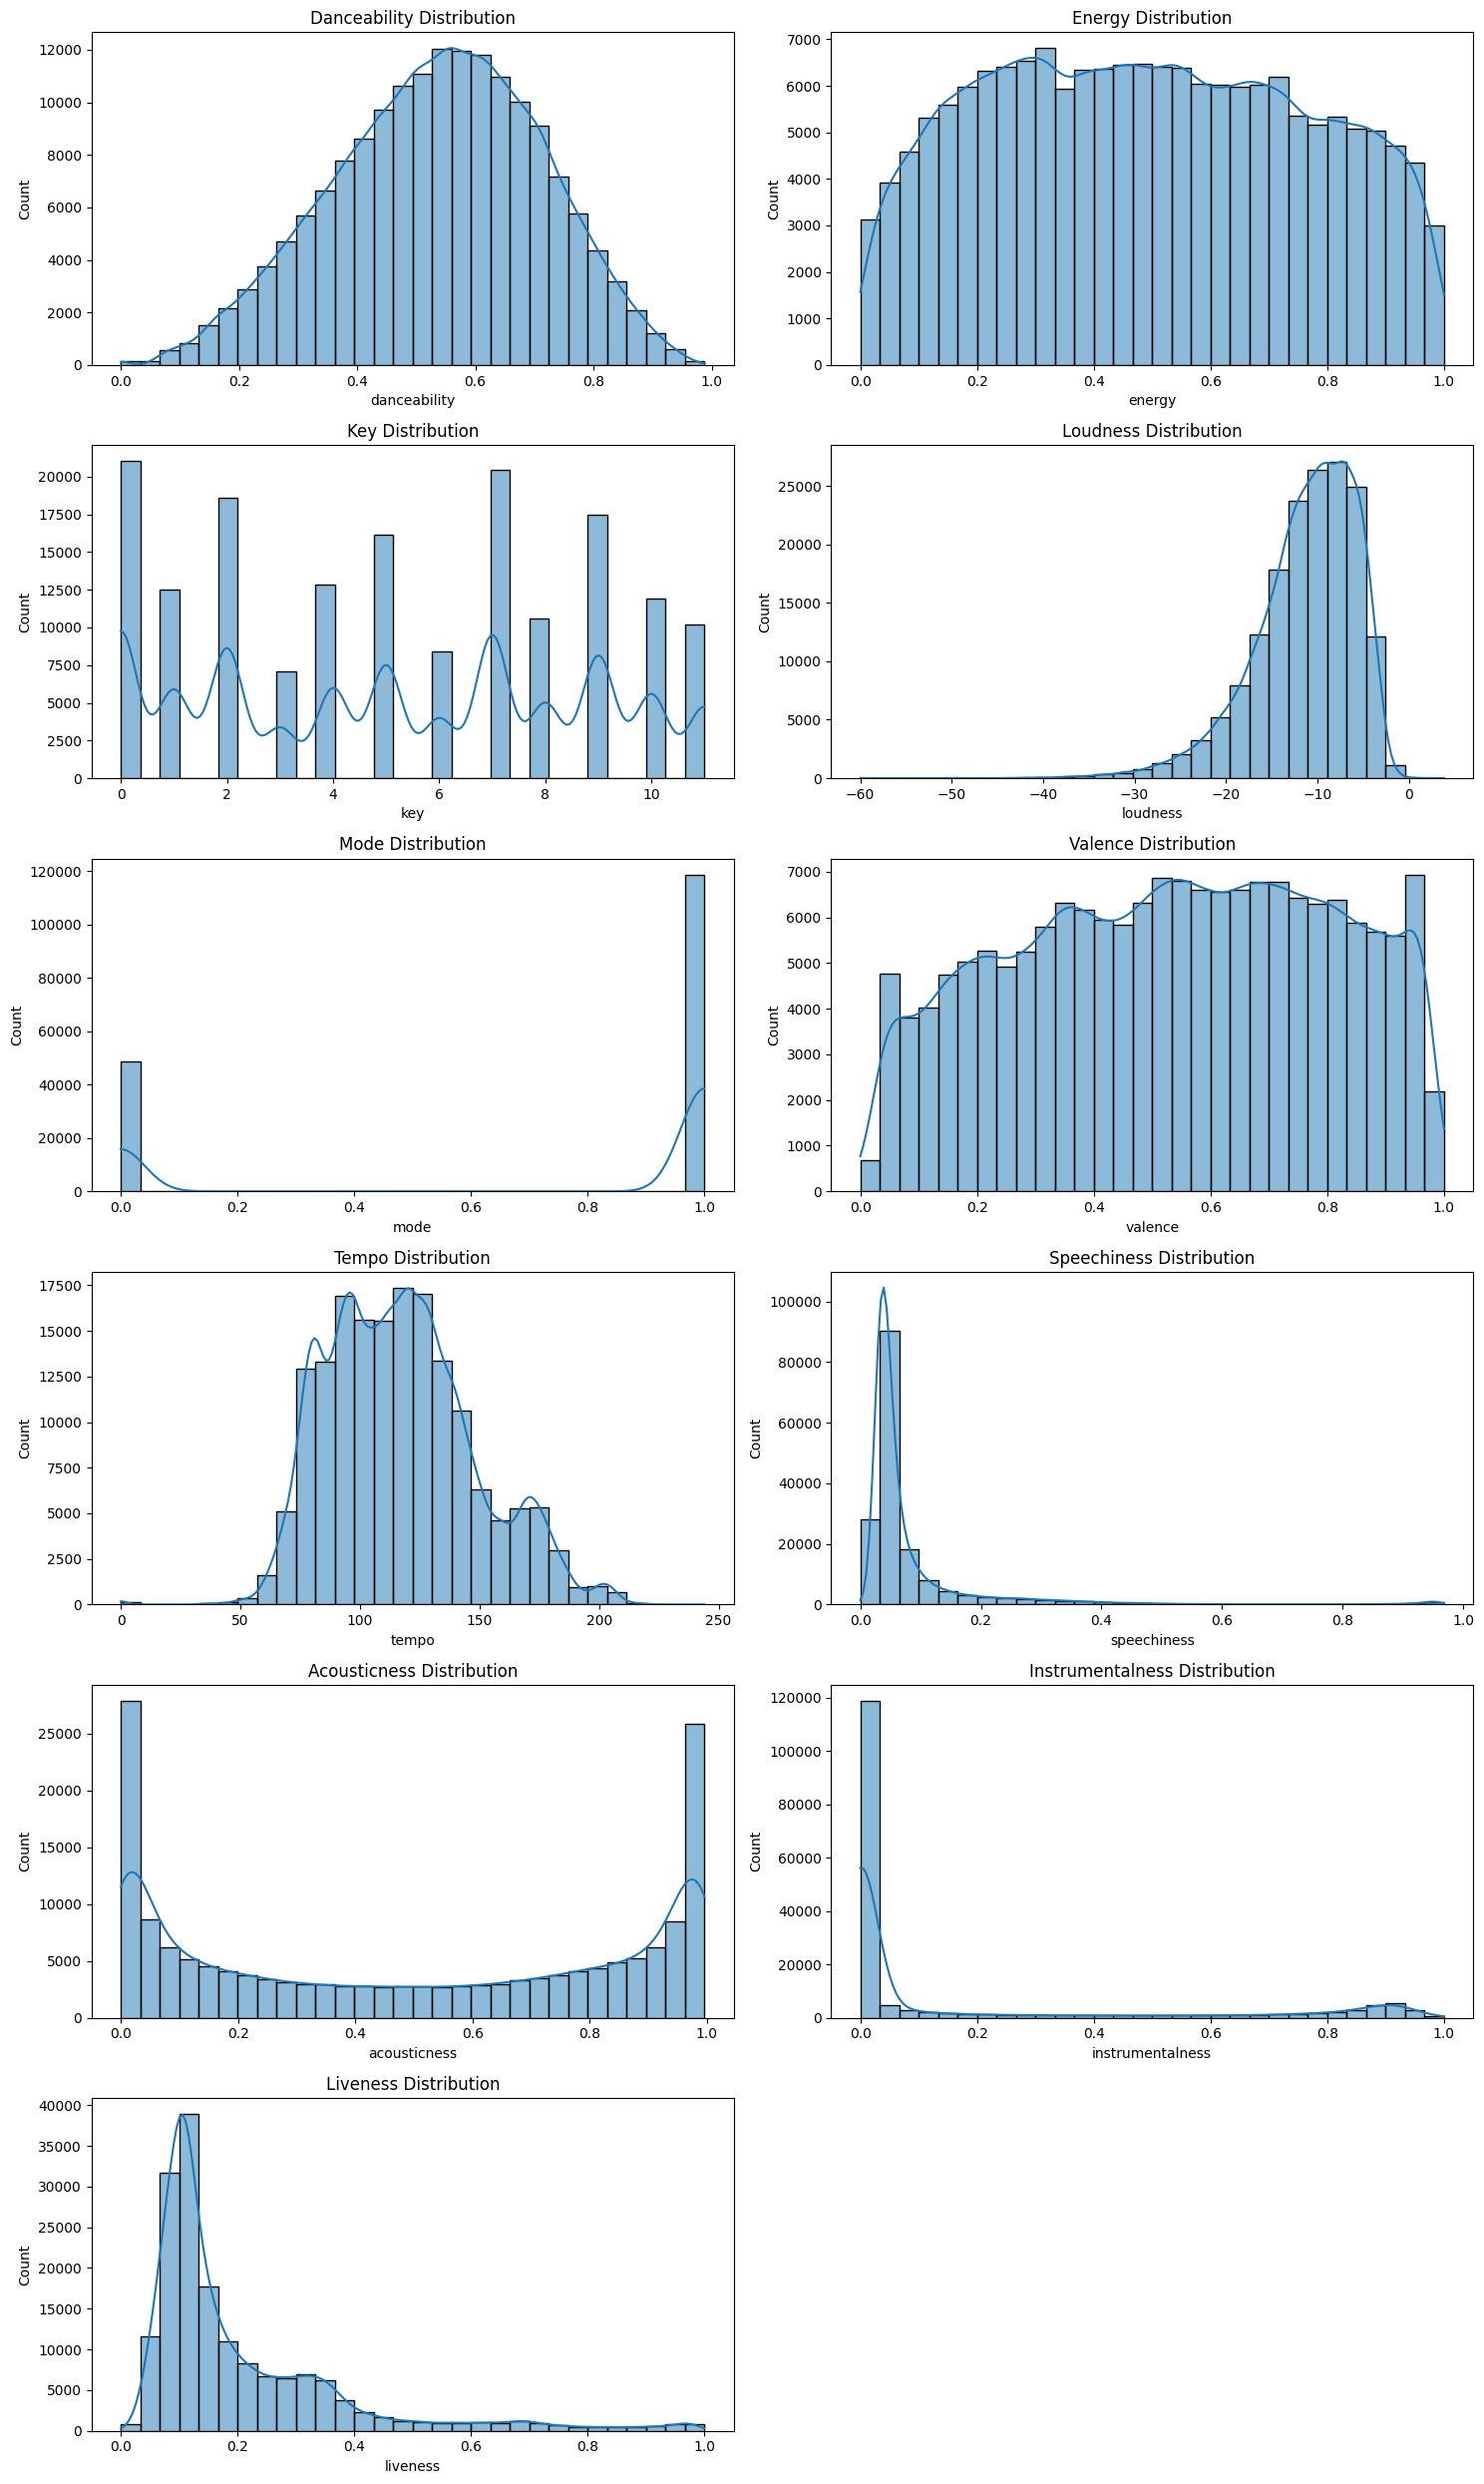

In [ ]:
all_audio_features = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'valence', 'tempo', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness'
]

Numerical_audio_features = [
    'danceability', 'energy', 'loudness',
    'valence', 'tempo', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness'
]

plt.figure(figsize=(15, 25))
for i, feature in enumerate(all_audio_features):
    plt.subplot(6, 2, i + 1)
    sns.histplot(data[feature].dropna(), bins=30, kde=True)
    plt.title(f'{feature.title()} Distribution')
plt.tight_layout()
plt.show()


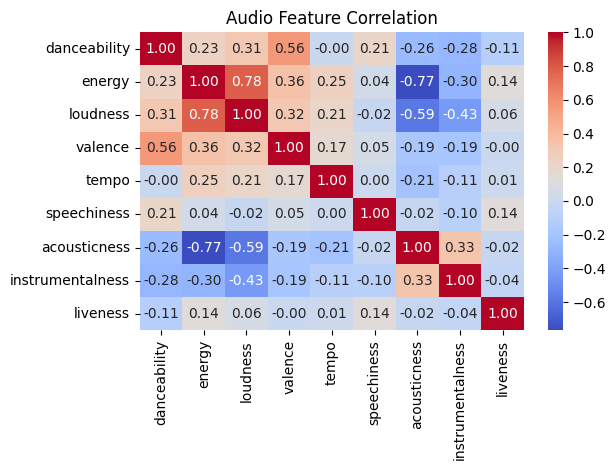

In [ ]:
sns.heatmap(data[Numerical_audio_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Audio Feature Correlation')
plt.tight_layout()
plt.show()


In [ ]:
print(data[Numerical_audio_features].var().sort_values())


speechiness           0.014424
danceability          0.030791
liveness              0.031221
valence               0.069433
energy                0.071210
instrumentalness      0.096087
acousticness          0.142135
loudness             31.684011
tempo               942.979031
dtype: float64


In [ ]:
# mode is intentionally excluded from similarity features —
# it is used as a hard filter in Stage 2 instead
audio_features = [#'danceability',
                  'energy',
                  'loudness',
                  #'valence',
                  #'tempo',
                  'acousticness']

data[audio_features] = data[audio_features].fillna(0)
# data['artist_genres'] = data['artist_genres'].fillna('')
data['artists'] = data['artists'].fillna('')

print('Features used for similarity:', audio_features)
print('Mode distribution (0=minor, 1=major):')
print(data['mode'].value_counts())


Features used for similarity: ['energy', 'loudness', 'acousticness']
Mode distribution (0=minor, 1=major):
mode
1    109202
0     44887
Name: count, dtype: int64


In [ ]:
# Drop duplicates based on the newly created 'combined_name'
data = data.drop_duplicates(subset=['combined_name']).reset_index(drop=True)
print(f'Shape after dropping combined_name duplicates: {data.shape}')

Shape after dropping combined_name duplicates: (154089, 14)


In [ ]:
scaler = StandardScaler()
audio_matrix = scaler.fit_transform(data[audio_features])

# Reset index so positional indexing stays consistent
data = data.reset_index(drop=True)

print(f'Audio matrix shape: {audio_matrix.shape}')


Audio matrix shape: (154089, 3)


In [ ]:
knn_model = NearestNeighbors(
    n_neighbors=50,      # larger than top_n because filters are applied later
    metric='euclidean',
    algorithm='brute'
)

knn_model.fit(audio_matrix)

NearestNeighbors(algorithm='brute', metric='euclidean', n_neighbors=50)

In [ ]:
def get_recommendations(combined_name_query, top_n=10):
    """
    Three-stage recommendation:
      Stage 1: Exclude songs by the same artist
      Stage 2: Exclude songs with a different mode
      Stage 3: Rank remaining using KNN + Euclidean distance
    """
...

    return recommendations

In [ ]:
recommended_songs = get_recommendations('ASIAN KUNG-FU GENERATION <> Re:Re:')
print(recommended_songs)


                                       combined_name  \
0                                Earshot <> Get Away   
1                            Lifehouse <> Falling In   
2                            Grouplove <> Lovely Cup   
3  Excision, Datsik, Dirtyphonics <> Deviance - D...   
4      The All-American Rejects <> One More Sad Song   
5                The Psychedelic Furs <> Love My Way   
6                     The Strokes <> Heart In a Cage   
7                         Blake Shelton <> Honey Bee   
8                              Trace Adkins <> Swing   
9                             Lady Gaga <> Americano   

                            name                         artists  mode  \
0                       Get Away                         Earshot     1   
1                     Falling In                       Lifehouse     1   
2                     Lovely Cup                       Grouplove     1   
3  Deviance - Dirtyphonics Remix  Excision, Datsik, Dirtyphonics     1   
4            

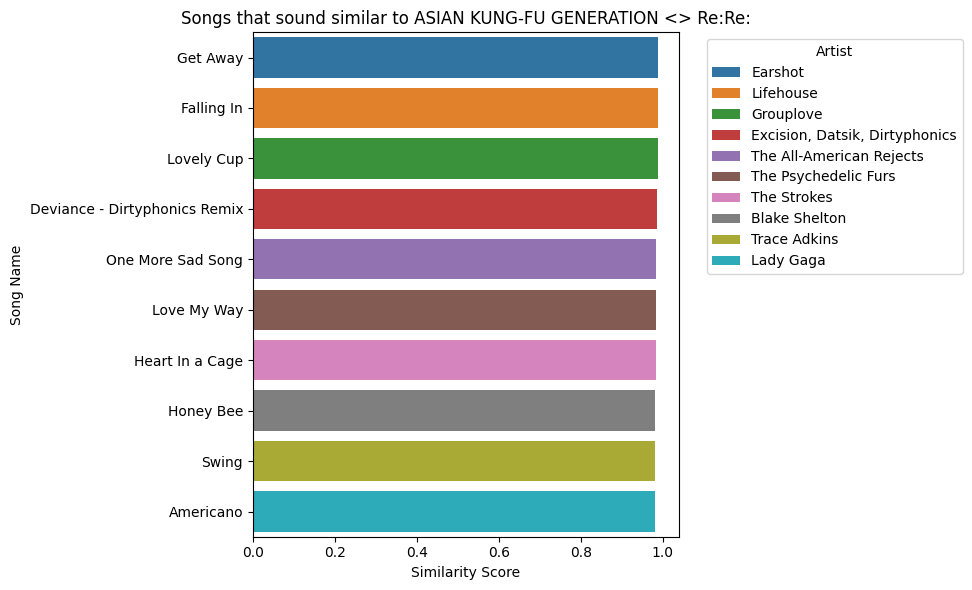

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=recommended_songs,
    y='name',
    x='similarity_score',
    hue='artists',
    dodge=False
)
plt.title('Songs that sound similar to ASIAN KUNG-FU GENERATION <> Re:Re:')
plt.xlabel('Similarity Score')
plt.ylabel('Song Name')
plt.legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Evaluation

In [ ]:
def query_to_rec_similarity(combined_name_query, top_n=10):
    recs = get_recommendations(combined_name_query, top_n=top_n)
    if recs is None or recs.empty:
        return None
    return recs['similarity_score'].mean()


def evaluate_query_to_rec(sample_n=200, top_n=10, random_state=42):
    sample = data.sample(n=min(sample_n, len(data)), random_state=random_state)
    scores = []
    for name in sample['combined_name']:
        s = query_to_rec_similarity(name, top_n=top_n)
        if s is not None:
            scores.append(s)
    scores = np.array(scores)
    print(f'[Metric 1] Query-to-Recommendation Similarity  (n={len(scores)}, top_n={top_n})')
    print(f'  Mean   : {scores.mean():.4f}')
    print(f'  Median : {np.median(scores):.4f}')
    print(f'  Std    : {scores.std():.4f}')
    print(f'  Min    : {scores.min():.4f}')
    print(f'  Max    : {scores.max():.4f}')
    return scores


m1_scores = evaluate_query_to_rec(sample_n=200, top_n=10)


[Metric 1] Query-to-Recommendation Similarity  (n=200, top_n=10)
  Mean   : 0.9426
  Median : 0.9501
  Std    : 0.0420
  Min    : 0.5817
  Max    : 0.9920
